# EDA and Model Selection – Voyage Fuel Optimizer

In this notebook we:
- Load and explore the ship fuel dataset.
- Clean the target variable.
- Build and compare regression models.
- Select the best model for fuel consumption prediction.

In [1]:
# Import libraries

# Data handling
import pandas as pd        # DataFrames
import numpy as np         # Numerical operations

# Visualization
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns            # Default plot styles

# Machine learning tools
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# To save/load models
import joblib

# For creating folders
import os

# Plot defaults
sns.set(style="whitegrid")

# Tell pandas to show more columns if needed
pd.set_option("display.max_columns", 50)

In [3]:
# Load the dataset
df = pd.read_csv("../data/ship_fuel_efficiency.csv")

# Show first few rows
df.head()

,ship_id,ship_type,route_id,month,distance,fuel_type,fuel_consumption,CO2_emissions,weather_conditions,engine_efficiency
0,NG001,Oil Service Boat,Warri-Bonny,January,132.26,HFO,3779.77,10625.76,Stormy,92.14
1,NG001,Oil Service Boat,Port Harcourt-Lagos,February,128.52,HFO,4461.44,12779.73,Moderate,92.98
2,NG001,Oil Service Boat,Port Harcourt-Lagos,March,67.30,HFO,1867.73,5353.01,Calm,87.61
3,NG001,Oil Service Boat,Port Harcourt-Lagos,April,71.68,Diesel,2393.51,6506.52,Stormy,87.42
4,NG001,Oil Service Boat,Lagos-Apapa,May,134.32,HFO,4267.19,11617.03,Calm,85.61


## Data overview

In [4]:
# Shape of data
print("Data shape (rows, cols):", df.shape)

# Check column names
print("\nColumns:", df.columns.tolist())

# Column dtypes
print("\nColumn dtypes:")
print(df.dtypes)

# Numeric summary
print("\nNumeric summary:")
print(df.describe())

Data shape (rows, cols): (1440, 10)

Columns: ['ship_id', 'ship_type', 'route_id', 'month', 'distance', 'fuel_type', 'fuel_consumption', 'CO2_emissions', 'weather_conditions', 'engine_efficiency']

Column dtypes:
ship_id                object
ship_type              object
route_id               object
month                  object
distance              float64
fuel_type              object
fuel_consumption      float64
CO2_emissions         float64
weather_conditions     object
engine_efficiency     float64
dtype: object

Numeric summary:
          distance  fuel_consumption  CO2_emissions  engine_efficiency
count  1440.000000       1440.000000    1440.000000        1440.000000
mean    151.753354       4844.246535   13365.454882          82.582924
std     108.472230       4892.352813   13567.650118           7.158289
min      20.080000        237.880000     615.680000          70.010000
25%      79.002500       1837.962500    4991.485000          76.255000
50%     123.465000       3060

In [5]:
# Unique values for categorical columns
cat_cols_check = ["ship_id", "ship_type", "route_id", "month", "fuel_type", "weather_conditions"]
for c in cat_cols_check:
    if c in df.columns:
        print(f"{c}: {sorted(df[c].dropna().unique())}")

ship_id: ['NG001', 'NG002', 'NG003', 'NG004', 'NG005', 'NG006', 'NG007', 'NG008', 'NG009', 'NG010', 'NG011', 'NG012', 'NG013', 'NG014', 'NG015', 'NG016', 'NG017', 'NG018', 'NG019', 'NG020', 'NG021', 'NG022', 'NG023', 'NG024', 'NG025', 'NG026', 'NG027', 'NG028', 'NG029', 'NG030', 'NG031', 'NG032', 'NG033', 'NG034', 'NG035', 'NG036', 'NG037', 'NG038', 'NG039', 'NG040', 'NG041', 'NG042', 'NG043', 'NG044', 'NG045', 'NG046', 'NG047', 'NG048', 'NG049', 'NG050', 'NG051', 'NG052', 'NG053', 'NG054', 'NG055', 'NG056', 'NG057', 'NG058', 'NG059', 'NG060', 'NG061', 'NG062', 'NG063', 'NG064', 'NG065', 'NG066', 'NG067', 'NG068', 'NG069', 'NG070', 'NG071', 'NG072', 'NG073', 'NG074', 'NG075', 'NG076', 'NG077', 'NG078', 'NG079', 'NG080', 'NG081', 'NG082', 'NG083', 'NG084', 'NG085', 'NG086', 'NG087', 'NG088', 'NG089', 'NG090', 'NG091', 'NG092', 'NG093', 'NG094', 'NG095', 'NG096', 'NG097', 'NG098', 'NG099', 'NG100', 'NG101', 'NG102', 'NG103', 'NG104', 'NG105', 'NG106', 'NG107', 'NG108', 'NG109', 'NG110', 

## Target and cleaning

In [6]:
# Choose target
target = "fuel_consumption"  

print("Target column:", target)

# Drop rows where target is missing
df = df.dropna(subset=[target])

# Remove extreme outliers in target using IQR rule
Q1 = df[target].quantile(0.25)
Q3 = df[target].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before = len(df)
df = df[(df[target] >= lower) & (df[target] <= upper)]
after = len(df)
print(f"Outlier filter: removed {before - after} rows; remaining rows: {after}")

df = df.reset_index(drop=True)

Target column: fuel_consumption
Outlier filter: removed 226 rows; remaining rows: 1214


## Features and preprocessing

In [7]:
# Define features
cat_cols = ["ship_type", "route_id", "fuel_type", "weather_conditions", "month"]
num_cols = ["distance", "engine_efficiency"]

# Check columns exist
for c in cat_cols + num_cols:
    if c not in df.columns:
        raise ValueError(f"Column '{c}' not found in dataset.")

# Build X and y
X = df[cat_cols + num_cols]
y = df[target]

print("Feature columns:", cat_cols + num_cols)
print("Number of samples:", X.shape[0])

Feature columns: ['ship_type', 'route_id', 'fuel_type', 'weather_conditions', 'month', 'distance', 'engine_efficiency']
Number of samples: 1214


In [8]:
# Preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        # One-hot encode categorical columns
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        # Pass numeric columns through unchanged
        ("num", "passthrough", num_cols),
    ]
)

## Train/test split and model comparison

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test, 80% train
    random_state=42     # reproducible split
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 971
Test samples: 243


In [10]:
# Define models
models = {
    "Linear": LinearRegression(),
    "RF": RandomForestRegressor(n_estimators=300, random_state=42),
    "GBM": GradientBoostingRegressor(n_estimators=300, random_state=42),
    "XGB": xgb.XGBRegressor(n_estimators=300, random_state=42, tree_method="hist"),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, mdl in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", mdl)
    ])
    
    mae_scores = -cross_val_score(
        pipe, X_train, y_train,
        cv=cv,
        scoring="neg_mean_absolute_error"
    )
    
    rmse_scores = np.sqrt(
        -cross_val_score(
            pipe, X_train, y_train,
            cv=cv,
            scoring="neg_mean_squared_error"
        )
    )
    
    r2_scores = cross_val_score(
        pipe, X_train, y_train,
        cv=cv,
        scoring="r2"
    )
    
    results.append({
        "model": name,
        "MAE": mae_scores.mean(),
        "RMSE": rmse_scores.mean(),
        "R2": r2_scores.mean(),
    })

res_df = pd.DataFrame(results).sort_values("R2", ascending=False)
print(res_df)

    model         MAE        RMSE        R2
1      RF  342.068821  460.876286  0.930590
2     GBM  352.680412  481.915413  0.923868
3     XGB  372.275142  516.900715  0.912724
0  Linear  430.124204  559.070271  0.897421


## Final model and test performance

In [11]:
# Pick best model
best_row = res_df.iloc[0]
best_name = best_row["model"]
print("Best model by CV R²:", best_name)
print(best_row)

# Instantiate best model
if best_name == "Linear":
    best_model = LinearRegression()
elif best_name == "RF":
    best_model = RandomForestRegressor(n_estimators=300, random_state=42)
elif best_name == "GBM":
    best_model = GradientBoostingRegressor(n_estimators=300, random_state=42)
elif best_name == "XGB":
    best_model = xgb.XGBRegressor(n_estimators=300, random_state=42, tree_method="hist")
else:
    raise ValueError("Unexpected model name.")

final_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", best_model)
])

final_pipe.fit(X_train, y_train)

Best model by CV R²: RF
model            RF
MAE      342.068821
RMSE     460.876286
R2          0.93059
Name: 1, dtype: object


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ship_type', 'route_id',
                                                   'fuel_type',
                                                   'weather_conditions',
                                                   'month']),
                                                 ('num', 'passthrough',
                                                  ['distance',
                                                   'engine_efficiency'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

In [12]:
# Evaluate on test set
y_pred_test = final_pipe.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("Test set performance:")
print(f"MAE:  {mae_test:.2f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"R²:   {r2_test:.4f}")

Test set performance:
MAE:  335.06
RMSE: 468.30
R²:   0.9308


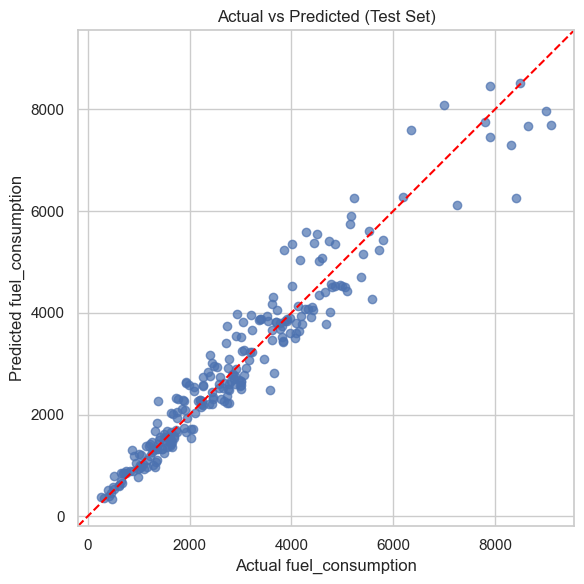

In [13]:
# Actual vs predicted plot (test set)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.7)
plt.axline((y_test.min(), y_test.min()), (y_test.max(), y_test.max()), color="red", linestyle="--")
plt.xlabel("Actual " + target)
plt.ylabel("Predicted " + target)
plt.title("Actual vs Predicted (Test Set)")
plt.tight_layout()
plt.show()

In [14]:
# Save model
os.makedirs("../models", exist_ok=True)
joblib.dump(final_pipe, "../models/fuel_model_rf_v1.joblib")
print("Model saved to ../models/fuel_model_rf_v1.joblib")

Model saved to ../models/fuel_model_rf_v1.joblib


## Model card (summary)

- **Task:** Predict `fuel_consumption`.
- **Model:** Random Forest Regressor (300 trees) in a scikit-learn pipeline with OneHotEncoder for categorical features.
- **Features:** `ship_type`, `route_id`, `fuel_type`, `weather_conditions`, `month`, `distance`, `engine_efficiency`.
- **Performance (CV):** R² ≈ 0.93, MAE ≈ 342, RMSE ≈ 461.
- **Use:** Baseline fuel estimator for voyage optimization and scenario analysis.